In [78]:
import pandas as pd

orders = pd.read_csv("/Users/stevencantu/Documents/archive/olist_orders_dataset.csv")
items = pd.read_csv("/Users/stevencantu/Documents/archive/olist_order_items_dataset.csv")
customers = pd.read_csv("/Users/stevencantu/Documents/archive/olist_customers_dataset.csv")

In [79]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [80]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [81]:
data_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in data_cols:
    orders[col] = pd.to_datetime(orders[col])

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [82]:
orders["delivery_days"] = orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
print(orders["delivery_days"].head())

0    8 days 10:28:40
1   13 days 18:46:08
2    9 days 09:27:40
3   13 days 05:00:36
4    2 days 20:58:23
Name: delivery_days, dtype: timedelta64[ns]


In [83]:
orders["delivery_days"] = orders["delivery_days"].dt.days
print(orders["delivery_days"].head())

0     8.0
1    13.0
2     9.0
3    13.0
4     2.0
Name: delivery_days, dtype: float64


In [84]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [85]:
orders["is_late"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]) > pd.Timedelta(0)
orders["is_late"].sum()

np.int64(7827)

In [86]:
orders["is_late"].sum() / orders["is_late"].count()

np.float64(0.07870998883760219)

In [87]:
print(f"{orders['is_late'].sum() / orders['is_late'].count() * 100:.2f}%")

7.87%


In [88]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [89]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [90]:
orders_customers = pd.merge(orders, customers, on="customer_id", how="left")

In [91]:
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,False,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,False,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,False,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,False,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [92]:
orders_customers.shape

(99441, 14)

In [93]:
orders.shape

(99441, 10)

In [94]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_days                  96476 non-null  float64       
 9   is_late                        99441 non-null  bool          
dtypes: bool(1), datetime64[ns](5), float64(1), object(3)
memory usage: 6.9+ MB


In [95]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [96]:
orders_customers.groupby("customer_state")["is_late"].mean()

customer_state
AC    0.037037
AL    0.230024
AM    0.040541
AP    0.044118
BA    0.135207
CE    0.146707
DF    0.068692
ES    0.120020
GO    0.079208
MA    0.188755
MG    0.054835
MS    0.113287
MT    0.066152
PA    0.120000
PB    0.106343
PE    0.104116
PI    0.153535
PR    0.048761
RJ    0.129474
RN    0.105155
RO    0.027668
RR    0.108696
RS    0.069887
SC    0.095133
SE    0.145714
SP    0.057179
TO    0.125000
Name: is_late, dtype: float64

In [97]:
late_by_state = orders_customers.groupby("customer_state")["is_late"].mean()
late_by_state.sort_values(ascending=False)

customer_state
AL    0.230024
MA    0.188755
PI    0.153535
CE    0.146707
SE    0.145714
BA    0.135207
RJ    0.129474
TO    0.125000
ES    0.120020
PA    0.120000
MS    0.113287
RR    0.108696
PB    0.106343
RN    0.105155
PE    0.104116
SC    0.095133
GO    0.079208
RS    0.069887
DF    0.068692
MT    0.066152
SP    0.057179
MG    0.054835
PR    0.048761
AP    0.044118
AM    0.040541
AC    0.037037
RO    0.027668
Name: is_late, dtype: float64

In [98]:
late_by_state = late_by_state.sort_values(ascending=False).reset_index()
late_by_state.columns = ["state", "late_rate"]
late_by_state["late_rate_pct"] = (late_by_state["late_rate"] * 100).round(2)
print(late_by_state.head(10))

  state  late_rate  late_rate_pct
0    AL   0.230024          23.00
1    MA   0.188755          18.88
2    PI   0.153535          15.35
3    CE   0.146707          14.67
4    SE   0.145714          14.57
5    BA   0.135207          13.52
6    RJ   0.129474          12.95
7    TO   0.125000          12.50
8    ES   0.120020          12.00
9    PA   0.120000          12.00


In [99]:
import matplotlib.pyplot as plt

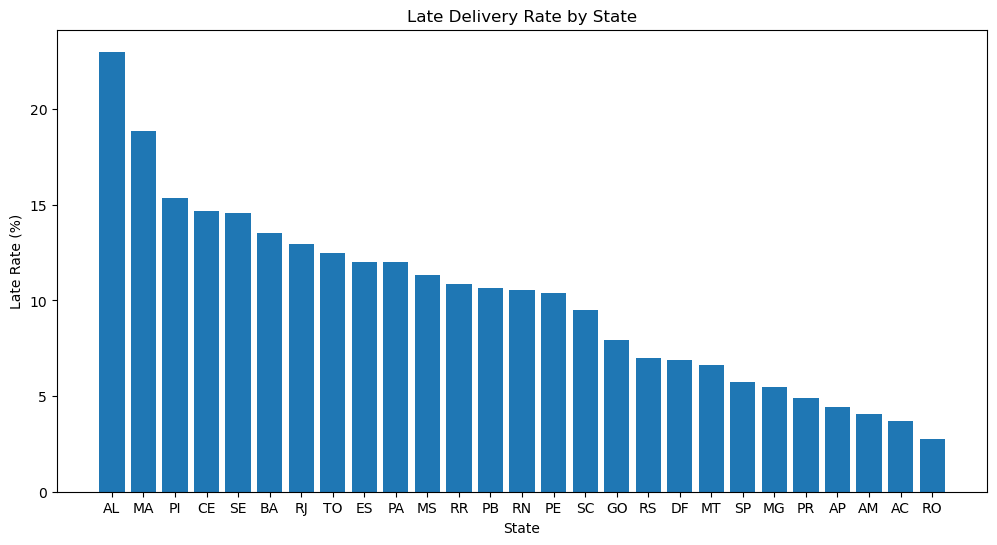

In [100]:
plt.figure(figsize=(12,6))
plt.bar(late_by_state["state"]
        , late_by_state["late_rate_pct"])
plt.title("Late Delivery Rate by State")
plt.xlabel("State")
plt.ylabel("Late Rate (%)")
plt.show()

In [101]:
plt.figure(figsize=(14, 6))
plt.bar(late_by_state["state"], late_by_state["late_rate_pct"], color=colors)
plt.title("Late Delivery Rate by State", fontsize=16)
plt.xlabel("State", fontsize=12)
plt.ylabel("Late Rate (%)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'colors' is not defined

<Figure size 1400x600 with 0 Axes>

In [102]:
colors = ["red" if rate > 15 else "steelblue" for rate in late_by_state["late_rate_pct"]]

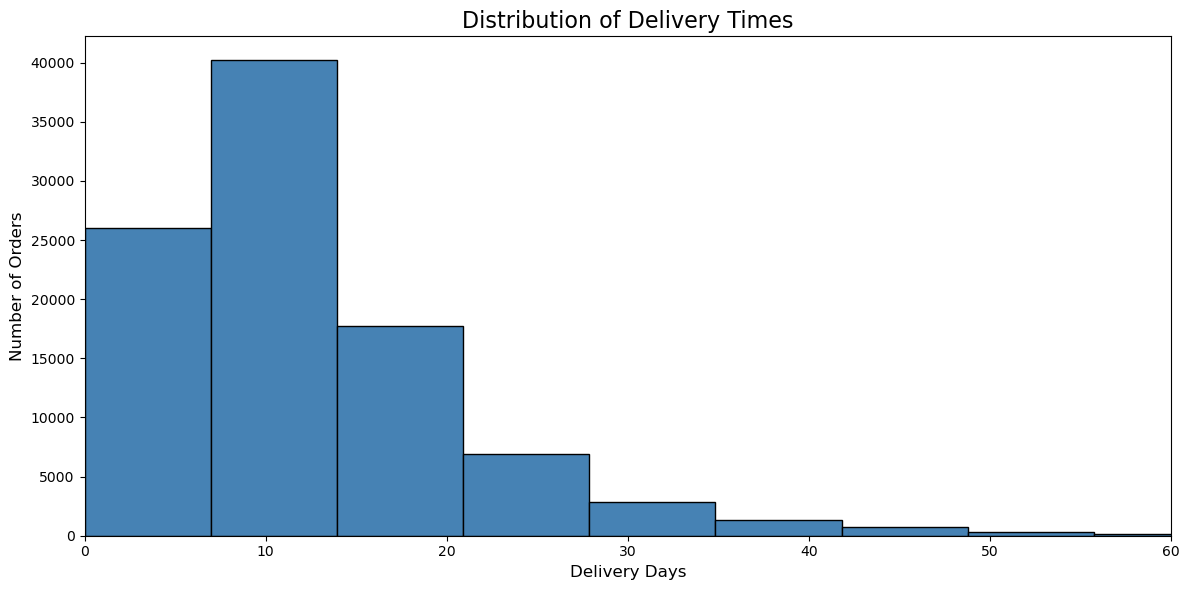

In [103]:
plt.figure(figsize=(12, 6))
plt.hist(orders["delivery_days"].dropna(), bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Delivery Times", fontsize=16)
plt.xlabel("Delivery Days", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xlim(0,60)
plt.tight_layout()
plt.show()

In [104]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [105]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [106]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_days                  96476 non-null  float64       
 9   is_late                        99441 non-null  bool          
dtypes: bool(1), datetime64[ns](5), float64(1), object(3)
memory usage: 6.9+ MB


In [107]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [108]:
products = pd.read_csv("/Users/stevencantu/Documents/archive/olist_products_dataset.csv")
translations = pd.read_csv("/Users/stevencantu/Documents/archive/product_category_name_translation.csv")

In [109]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [110]:
translations.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [111]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [112]:
translations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [113]:
products_translated = pd.merge(products, translations, on="product_category_name", how="left")


In [114]:
products_translated.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [115]:
items_products = pd.merge(items, products_translated, on="product_id", how="left")

In [116]:
orders_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_days                  96476 non-null  float64       
 9   is_late                        99441 non-null  bool          
 10  customer_unique_id             99441 non-null  object        
 11  customer_zip_co

In [117]:
items_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   product_category_name          111047 non-null  object 
 8   product_name_lenght            111047 non-null  float64
 9   product_description_lenght     111047 non-null  float64
 10  product_photos_qty             111047 non-null  float64
 11  product_weight_g               112632 non-null  float64
 12  product_length_cm             

In [118]:
full_df = pd.merge(items_products, orders_customers, on="order_id")

In [119]:
full_df.shape

(112650, 29)

In [120]:
full_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0,False,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0,False,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,7.0,False,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0,False,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0,False,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


In [121]:
full_df.groupby("product_category_name_english")["is_late"].mean()

product_category_name_english
agro_industry_and_commerce    0.042453
air_conditioning              0.037037
art                           0.071770
arts_and_craftmanship         0.083333
audio                         0.126374
                                ...   
stationery                    0.078665
tablets_printing_image        0.072289
telephony                     0.081188
toys                          0.072626
watches_gifts                 0.080955
Name: is_late, Length: 71, dtype: float64

In [122]:
worst_category = full_df.groupby("product_category_name_english")["is_late"].mean().sort_values(ascending=False).reset_index()

In [123]:
worst_category.head(10)

,product_category_name_english,is_late
0,home_comfort_2,0.166667
1,furniture_mattress_and_upholstery,0.131579
2,audio,0.126374
3,fashion_underwear_beach,0.122137
4,christmas_supplies,0.117647
5,books_technical,0.108614
6,home_confort,0.101382
7,construction_tools_lights,0.098684
8,electronics,0.096133
9,food,0.096078


In [124]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  object        
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   product_category_name          111047 non-null  object        
 8   product_name_lenght            111047 non-null  float64       
 9   product_description_lenght     111047 non-null  float64       
 10  product_photos_qty             111047 non-null  float64       
 11  

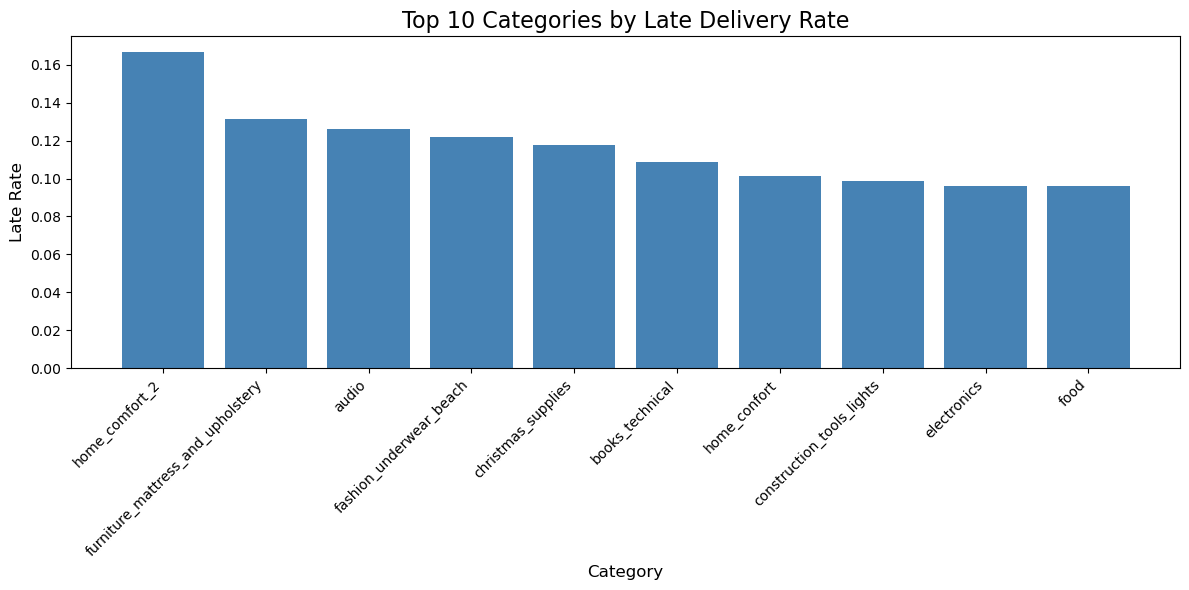

In [125]:
plt.figure(figsize=(12, 6))
plt.bar(worst_category.head(10)["product_category_name_english"], worst_category.head(10)["is_late"], color="steelblue")
plt.title("Top 10 Categories by Late Delivery Rate", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Late Rate", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [126]:
full_df.groupby("product_category_name_english")["delivery_days"].mean()

product_category_name_english
agro_industry_and_commerce    11.223301
air_conditioning              11.792388
art                           10.873096
arts_and_craftmanship          5.291667
audio                         12.883978
                                ...    
stationery                    12.282644
tablets_printing_image        12.578313
telephony                     12.383747
toys                          11.233499
watches_gifts                 12.191736
Name: delivery_days, Length: 71, dtype: float64

In [127]:
delivery_by_category = full_df.groupby("product_category_name_english")["delivery_days"].mean().sort_values(ascending=False).reset_index()

In [129]:
delivery_by_category.head(10)

,product_category_name_english,delivery_days
0,office_furniture,20.386691
1,christmas_supplies,15.300000
2,security_and_services,15.000000
3,fashion_shoes,14.933852
4,home_comfort_2,14.066667
5,furniture_mattress_and_upholstery,13.891892
6,home_appliances_2,13.424242
7,furniture_living_room,13.294949
8,fashion_underwear_beach,13.275591
9,garden_tools,13.231959


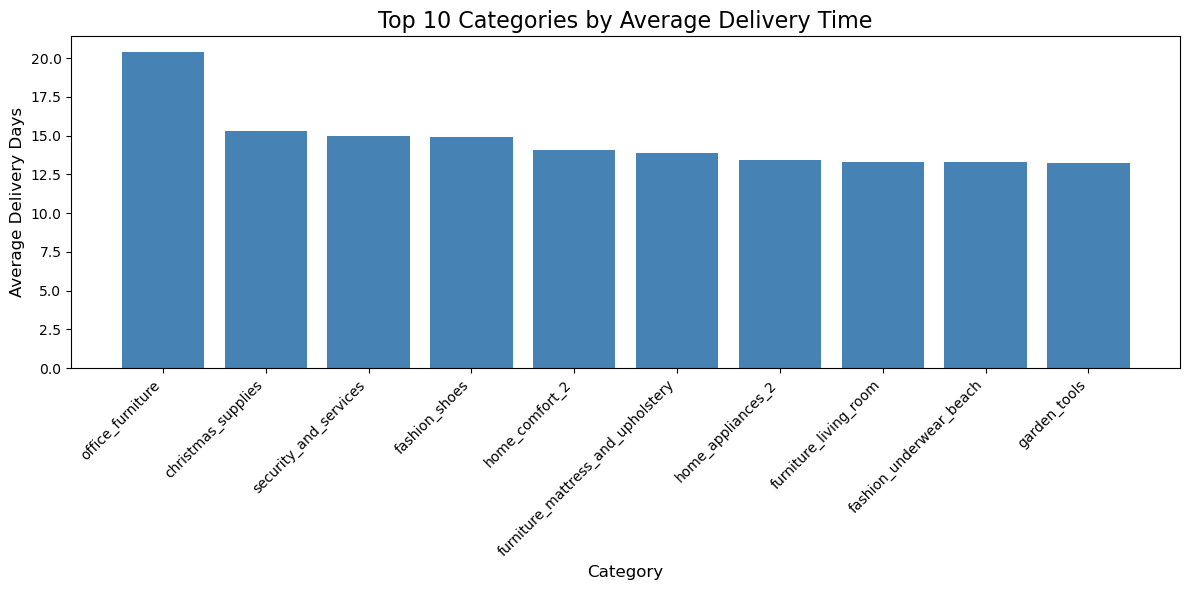

In [130]:
plt.figure(figsize=(12, 6))
plt.bar(delivery_by_category.head(10)["product_category_name_english"], delivery_by_category.head(10)["delivery_days"], color="steelblue")
plt.title("Top 10 Categories by Average Delivery Time", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Average Delivery Days", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [132]:
late_by_state.to_csv("late_by_state.csv", index=False)
worst_category.to_csv("late_rate_by_category.csv", index=False)
delivery_by_category.to_csv("delivery_time_by_category.csv", index=False)

# Supply Chain Delivery Performance Analysis

## Objective
Analyze delivery performance across Brazil's largest e-commerce platform (Olist) 
to identify operational bottlenecks in shipping and fulfillment.

## Key Findings
- **7.87%** of orders were delivered late overall
- Northeastern states (AL, MA, PI) have significantly higher late rates (15-23%) 
  compared to the national average — likely due to distance from major 
  distribution hubs in São Paulo
- **Office furniture** has the longest average delivery time (20+ days), 
  while categories like **audio** and **fashion_underwear_beach** have 
  disproportionately high late rates relative to their delivery speed
- Delivery time and late rate are **not directly correlated** — some categories 
  ship slowly but reliably, while others ship faster but miss tighter estimates

## Tools Used
Python, Pandas, Matplotlib

## Data Source
Brazilian E-Commerce Public Dataset by Olist (Kaggle)

In [133]:
import os
print(os.getcwd())

/Users/stevencantu
